### 1. Import Libraries


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import HANConv
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

### 2. Generate Synthetic Data

In [5]:
# --- 1. Gerar dados sintéticos com padrões realistas ---
num_users = 15
num_accounts = 15
num_devices = 10
num_transactions = 50

def create_user_features(n):
    idade = np.random.randint(18,70,n)
    tempo_conta = np.random.randint(1,15,n)
    risco = np.random.rand(n)
    return torch.tensor(np.vstack([idade, tempo_conta, risco, np.random.rand(n), np.random.rand(n)]).T, dtype=torch.float)

def create_account_features(n):
    saldo = np.random.rand(n)*10000
    tipo = np.random.randint(0,2,n)
    historico = np.random.rand(n)
    return torch.tensor(np.vstack([saldo, tipo, historico, np.random.rand(n)]).T, dtype=torch.float)

def create_device_features(n):
    idade_disp = np.random.randint(0,5,n)
    tipo_disp = np.random.randint(0,3,n)
    return torch.tensor(np.vstack([idade_disp, tipo_disp, np.random.rand(n)]).T, dtype=torch.float)

def create_transaction_features(n):
    valor = np.random.rand(n)*5000
    hora = np.random.randint(0,24,n)
    freq_usuario = np.random.randint(1,10,n)
    return torch.tensor(np.vstack([valor, hora, freq_usuario, np.random.rand(n), np.random.rand(n), np.random.rand(n)]).T, dtype=torch.float)

data = HeteroData()
data['user'].x = create_user_features(num_users)
data['account'].x = create_account_features(num_accounts)
data['device'].x = create_device_features(num_devices)
data['transaction'].x = create_transaction_features(num_transactions)

# Conectar nós aleatoriamente
user_account_edges = (torch.randint(0,num_users,(num_accounts,)), torch.arange(num_accounts))
account_transaction_edges = (torch.randint(0,num_accounts,(num_transactions,)), torch.arange(num_transactions))
user_device_edges = (torch.randint(0,num_users,(num_devices,)), torch.arange(num_devices))
device_transaction_edges = (torch.randint(0,num_devices,(num_transactions,)), torch.arange(num_transactions))

data['user','possui','account'].edge_index = torch.stack(user_account_edges)
data['account','realizou','transaction'].edge_index = torch.stack(account_transaction_edges)
data['user','utiliza','device'].edge_index = torch.stack(user_device_edges)
data['device','executou','transaction'].edge_index = torch.stack(device_transaction_edges)

# Labels de fraude
labels = torch.zeros(num_transactions, dtype=torch.long)
fraud_indices = np.random.choice(num_transactions, size=10, replace=False)
labels[fraud_indices] = 1
data['transaction'].x[fraud_indices,0] *= 3
data['transaction'].x[fraud_indices,1] = torch.tensor(np.random.randint(0,6,len(fraud_indices)), dtype=torch.float)
data['transaction'].y = labels

### 3. Define the HAN Model

In [7]:
# --- 2. Definir modelo HAN ---
class FraudHAN(nn.Module):
    def __init__(self, metadata, in_channels, hidden_channels, out_channels, heads=2):
        super().__init__()
        self.han1 = HANConv(in_channels, hidden_channels, metadata, heads=heads)
        self.fc = nn.Linear(hidden_channels, out_channels)
    
    def forward(self, x_dict, edge_index_dict):
        x = self.han1(x_dict, edge_index_dict)
        transaction_emb = x['transaction']
        out = self.fc(transaction_emb)
        return out, transaction_emb

# Metadata de grafos
metadata = (list(data.node_types), list(data.edge_types))

in_channels = { 'user':5, 'account':4, 'device':3, 'transaction':6 }
model = FraudHAN(metadata, in_channels, hidden_channels=16, out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

### 4. Train the Model

In [8]:
# --- 3. Treinamento ---
for epoch in range(150):
    model.train()
    optimizer.zero_grad()
    out, emb = model(data.x_dict, data.edge_index_dict)
    loss = loss_fn(out, data['transaction'].y)
    loss.backward()
    optimizer.step()
    if (epoch+1)%30==0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 30, Loss: 8.1326
Epoch 60, Loss: 0.5290
Epoch 90, Loss: 0.5183
Epoch 120, Loss: 0.5044
Epoch 150, Loss: 0.5009


### 5. Evaluate the Model

In [9]:
# --- 4. Avaliação ---
model.eval()
with torch.no_grad():
    out, emb = model(data.x_dict, data.edge_index_dict)
    preds = out.argmax(dim=1)
    acc = (preds == data['transaction'].y).sum().item()/num_transactions
    print(f"\nAccuracy: {acc:.2f}")


Accuracy: 0.80


### 6. Visualize Embeddings with t-SNE

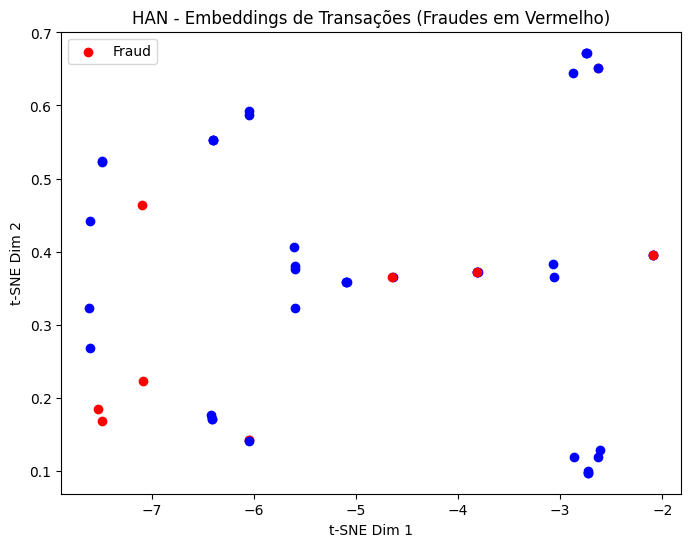

In [10]:
# --- 5. Visualização embeddings com t-SNE ---
emb_np = emb.numpy()
tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(emb_np)
labels_np = data['transaction'].y.numpy()

plt.figure(figsize=(8,6))
for i in range(num_transactions):
    if labels_np[i]==1:
        plt.scatter(emb_2d[i,0], emb_2d[i,1], c='red', label='Fraud' if i==fraud_indices[0] else "")
    else:
        plt.scatter(emb_2d[i,0], emb_2d[i,1], c='blue', label='Normal' if i==0 else "")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.title("HAN - Embeddings de Transações (Fraudes em Vermelho)")
plt.legend()
plt.show()